<a href="https://colab.research.google.com/github/RDRamosU/cr-graduados-steam-analisis/blob/main/notebooks/04_visualizaciones_hallazgos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto 1 — Graduados STEAM en Costa Rica 2014–2022
## Notebook 04 — Visualizaciones y hallazgos

**Autor:** Ruben Dario Ramos Ulate
**Fuente:** OPES-CONARE — Repositorio Institucional  
**Fecha:** Junio 2026  

---

## 1. Configuracion del entorno

In [2]:
!pip install pdfplumber -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import requests
import os

# Estilo general de los graficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'DejaVu Sans'

# Carpeta para exportar graficos
os.makedirs("assests/graficas", exist_ok=True)

print("Entorno configurado ✓")

Entorno configurado ✓


## 2. Carga del dataset consolidado

In [3]:
import requests

url_1 = "https://github.com/RDRamosU/cr-graduados-steam-analisis/raw/main/data/raw/OPES_44_2023_Picado_C_estadisticas_diplomas_universidades_estatales_2014_2021.pdf"
url_2 = "https://github.com/RDRamosU/cr-graduados-steam-analisis/raw/main/data/raw/OPES_108_2023_Picado_C_estadisticas_diplomas_otorgados_universidades_estatales_2018_2022.pdf"

import pdfplumber

for url, nombre in [(url_1, "OPES_2014_2021.pdf"), (url_2, "OPES_2018_2022.pdf")]:
    r = requests.get(url)
    with open(nombre, "wb") as f:
        f.write(r.content)

print("PDFs descargados ✓")

# Reconstruir dataset consolidado
años_doc1 = [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
df_doc1 = pd.DataFrame({
    'año': años_doc1,
    'total_diplomas': [14990, 15470, 15501, 16793, 16944, 17347, 16051, 21303],
    'steam_total':    [5169,  5525,  5711,  6468,  6154,  6654,  5830,  7007],
    'steam_mujer':    [2259,  2445,  2553,  2836,  2816,  3049,  2828,  3246],
    'steam_hombre':   [2910,  3080,  3158,  3632,  3338,  3605,  3002,  3761],
    'no_steam_total': [9821,  9945,  9790,  10325, 10790, 10693, 10221, 14296],
    'no_steam_mujer': [6583,  6778,  6586,  7172,  7535,  7510,  7287,  10223],
    'no_steam_hombre':[3238,  3167,  3204,  3153,  3255,  3183,  2934,  4073],
    'fuente': 'OPES_2014_2021'
})

df_doc2 = pd.DataFrame({
    'año': [2018, 2019, 2020, 2021, 2022],
    'total_diplomas': [16944, 17347, 16051, 21303, 20754],
    'steam_total':    [6154,  6654,  5830,  7007,  7273],
    'steam_mujer':    [2816,  3049,  2828,  3246,  3440],
    'steam_hombre':   [3338,  3605,  3002,  3761,  3833],
    'no_steam_total': [10790, 10693, 10221, 14296, 13481],
    'no_steam_mujer': [7535,  7510,  7287,  10223, 9646],
    'no_steam_hombre':[3255,  3183,  2934,  4073,  3835],
    'fuente': 'OPES_2018_2022'
})

df_final = pd.concat([df_doc1, df_doc2[df_doc2['año'] == 2022]], ignore_index=True)
df_final['pct_steam'] = (df_final['steam_total'] / df_final['total_diplomas'] * 100).round(1)
df_final['pct_steam_mujer'] = (df_final['steam_mujer'] / df_final['steam_total'] * 100).round(1)
df_final['pct_steam_hombre'] = (df_final['steam_hombre'] / df_final['steam_total'] * 100).round(1)

print(f"Dataset cargado: {len(df_final)} registros · {df_final['año'].min()}–{df_final['año'].max()} ✓")

PDFs descargados ✓
Dataset cargado: 9 registros · 2014–2022 ✓


## 3. Visualizacion 1 - Tendencia de graduados STEAM 2014-2022

FileNotFoundError: [Errno 2] No such file or directory: 'assets/graficas/01_tendencia_steam_2014_2022.png'

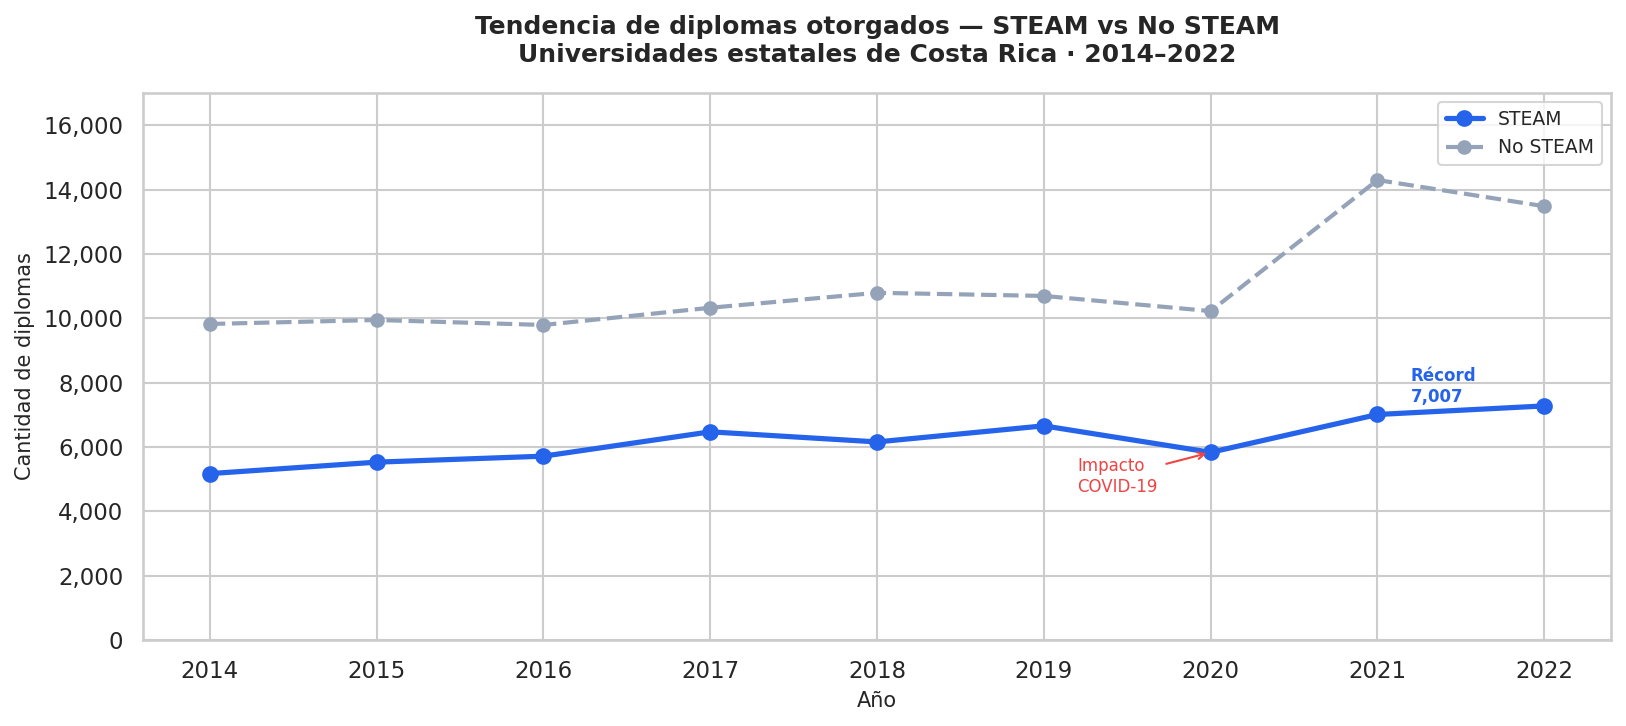

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(df_final['año'], df_final['steam_total'],
        color='#2563EB', linewidth=2.5, marker='o', markersize=7, label='STEAM')
ax.plot(df_final['año'], df_final['no_steam_total'],
        color='#94A3B8', linewidth=2, marker='o', markersize=6,
        linestyle='--', label='No STEAM')

# Anotación caída 2020
ax.annotate('Impacto\nCOVID-19', xy=(2020, 5830), xytext=(2019.2, 4600),
            arrowprops=dict(arrowstyle='->', color='#EF4444'),
            fontsize=8, color='#EF4444')

# Anotación pico 2021
ax.annotate('Récord\n7,007', xy=(2021, 7007), xytext=(2021.2, 7400),
            fontsize=8, color='#2563EB', fontweight='bold')

ax.set_title('Tendencia de diplomas otorgados — STEAM vs No STEAM\nUniversidades estatales de Costa Rica · 2014–2022',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Año', fontsize=10)
ax.set_ylabel('Cantidad de diplomas', fontsize=10)
ax.set_xticks(df_final['año'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=9)
ax.set_ylim(0, 17000)

plt.tight_layout()
plt.savefig("assets/graficas/01_tendencia_steam_2014_2022.png", bbox_inches='tight')
plt.show()
print("Gráfica 1 exportada ✓")

## 4. Visualizacion 2 - Porcentaje STEAM del total de diplomas por año

FileNotFoundError: [Errno 2] No such file or directory: 'assets/graficas/02_pct_steam_por_año.png'

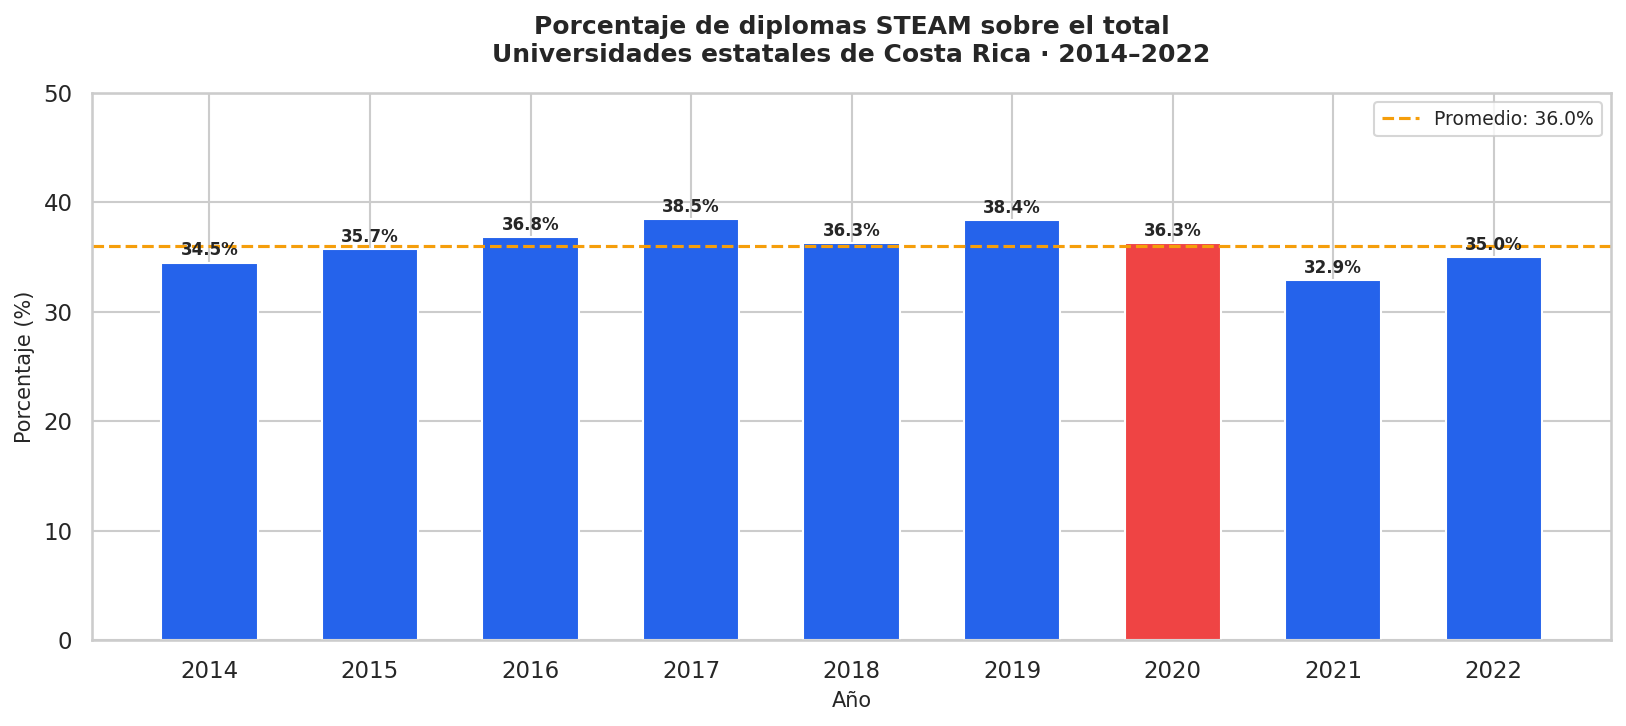

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))

colores = ['#EF4444' if año == 2020 else '#2563EB' for año in df_final['año']]

bars = ax.bar(df_final['año'], df_final['pct_steam'], color=colores,
              edgecolor='white', width=0.6)

# Etiquetas sobre cada barra
for bar, val in zip(bars, df_final['pct_steam']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_title('Porcentaje de diplomas STEAM sobre el total\nUniversidades estatales de Costa Rica · 2014–2022',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Año', fontsize=10)
ax.set_ylabel('Porcentaje (%)', fontsize=10)
ax.set_xticks(df_final['año'])
ax.set_ylim(0, 50)
ax.axhline(y=df_final['pct_steam'].mean(), color='#F59E0B',
           linestyle='--', linewidth=1.5, label=f"Promedio: {df_final['pct_steam'].mean():.1f}%")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("assets/graficas/02_pct_steam_por_año.png", bbox_inches='tight')
plt.show()
print("Gráfica 2 exportada ✓")

## 5. Visualizacion 3. Brecha de genero en graduacones STEAM

FileNotFoundError: [Errno 2] No such file or directory: 'assets/graficas/03_brecha_genero_steam.png'

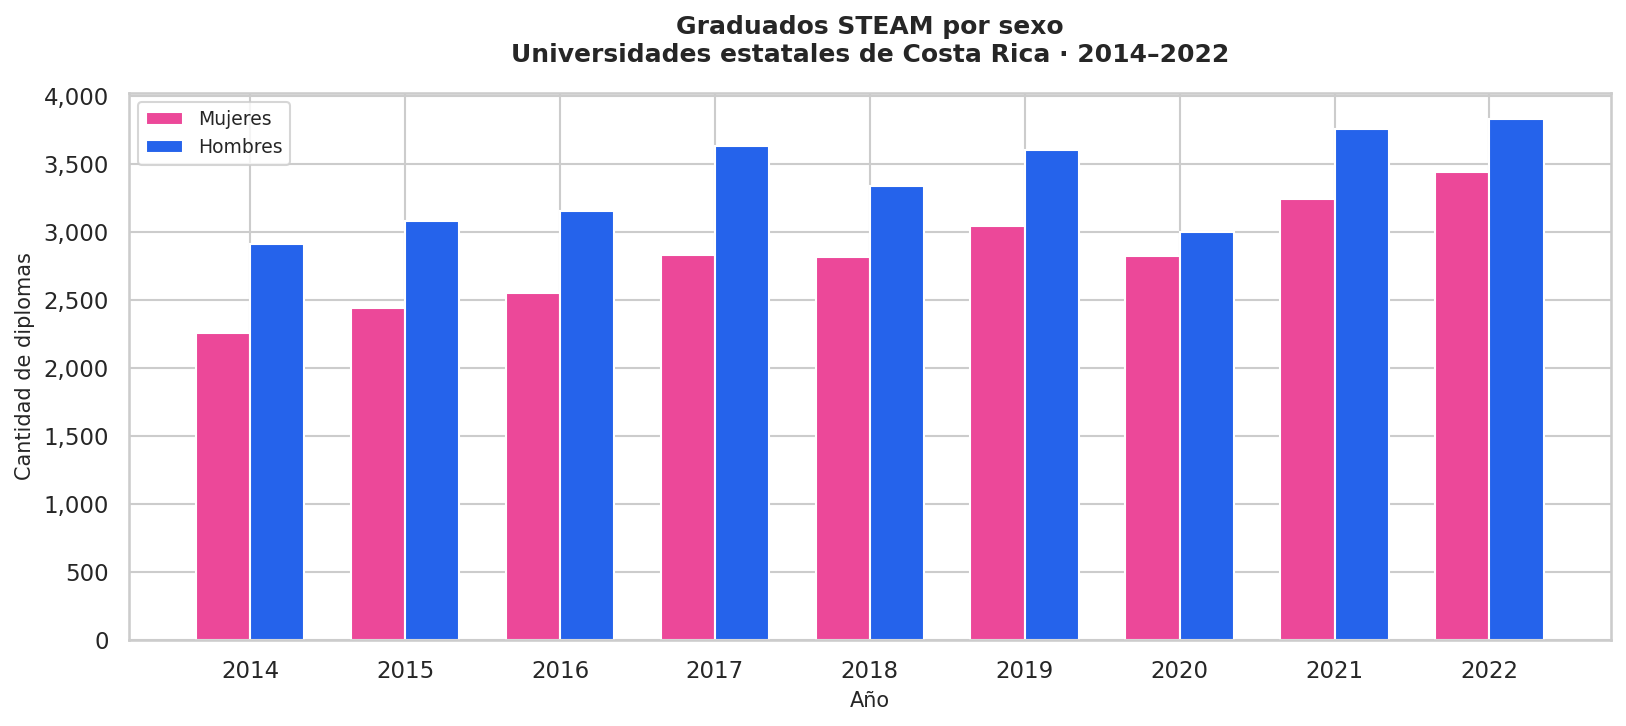

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(df_final['año']))
ancho = 0.35

bars_m = ax.bar(x - ancho/2, df_final['steam_mujer'],
                ancho, label='Mujeres', color='#EC4899', edgecolor='white')
bars_h = ax.bar(x + ancho/2, df_final['steam_hombre'],
                ancho, label='Hombres', color='#2563EB', edgecolor='white')

ax.set_title('Graduados STEAM por sexo\nUniversidades estatales de Costa Rica · 2014–2022',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Año', fontsize=10)
ax.set_ylabel('Cantidad de diplomas', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(df_final['año'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("assets/graficas/03_brecha_genero_steam.png", bbox_inches='tight')
plt.show()
print("Gráfica 3 exportada ✓")

## 6. Visualizacion 4. Evolucion del porcentaje de mujeres en STEAM

FileNotFoundError: [Errno 2] No such file or directory: 'assets/graficas/04_evolucion_mujeres_steam.png'

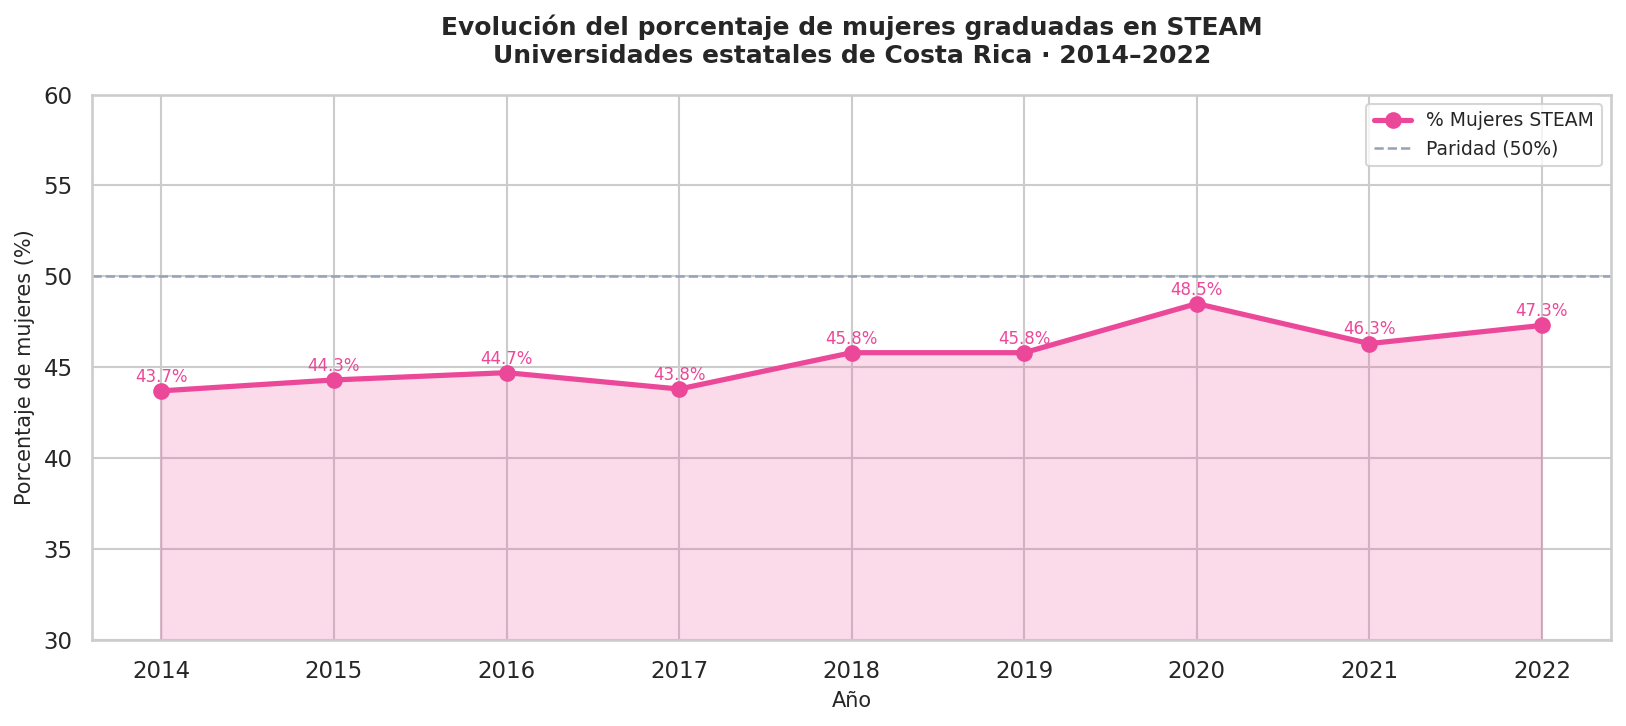

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.fill_between(df_final['año'], df_final['pct_steam_mujer'],
                alpha=0.2, color='#EC4899')
ax.plot(df_final['año'], df_final['pct_steam_mujer'],
        color='#EC4899', linewidth=2.5, marker='o', markersize=7, label='% Mujeres STEAM')

ax.axhline(y=50, color='#94A3B8', linestyle='--',
           linewidth=1.2, label='Paridad (50%)')

for x, y in zip(df_final['año'], df_final['pct_steam_mujer']):
    ax.text(x, y + 0.5, f'{y}%', ha='center', fontsize=8, color='#EC4899')

ax.set_title('Evolución del porcentaje de mujeres graduadas en STEAM\nUniversidades estatales de Costa Rica · 2014–2022',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Año', fontsize=10)
ax.set_ylabel('Porcentaje de mujeres (%)', fontsize=10)
ax.set_xticks(df_final['año'])
ax.set_ylim(30, 60)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("assets/graficas/04_evolucion_mujeres_steam.png", bbox_inches='tight')
plt.show()
print("Gráfica 4 exportada ✓")

## 7. Hallazgos principales


In [9]:
print("=" * 55)
print("HALLAZGOS — GRADUADOS STEAM CR 2014–2022")
print("=" * 55)

# Hallazgo 1: crecimiento total
steam_2014 = df_final[df_final['año'] == 2014]['steam_total'].values[0]
steam_2022 = df_final[df_final['año'] == 2022]['steam_total'].values[0]
crecimiento = ((steam_2022 - steam_2014) / steam_2014 * 100).round(1)
print(f"\n1. CRECIMIENTO 2014–2022")
print(f"   STEAM 2014: {steam_2014:,} → 2022: {steam_2022:,}")
print(f"   Crecimiento total: +{crecimiento}%")

# Hallazgo 2: impacto COVID
steam_2019 = df_final[df_final['año'] == 2019]['steam_total'].values[0]
steam_2020 = df_final[df_final['año'] == 2020]['steam_total'].values[0]
caida = ((steam_2020 - steam_2019) / steam_2019 * 100).round(1)
print(f"\n2. IMPACTO COVID-19")
print(f"   STEAM 2019: {steam_2019:,} → 2020: {steam_2020:,}")
print(f"   Variación: {caida}%")

# Hallazgo 3: brecha de género
promedio_mujer = df_final['pct_steam_mujer'].mean().round(1)
promedio_hombre = df_final['pct_steam_hombre'].mean().round(1)
print(f"\n3. BRECHA DE GÉNERO PROMEDIO 2014–2022")
print(f"   Mujeres STEAM: {promedio_mujer}%")
print(f"   Hombres STEAM: {promedio_hombre}%")
print(f"   Brecha: {(promedio_hombre - promedio_mujer).round(1)} puntos porcentuales")

# Hallazgo 4: proporción STEAM promedio
pct_promedio = df_final['pct_steam'].mean().round(1)
print(f"\n4. PROPORCIÓN STEAM PROMEDIO")
print(f"   {pct_promedio}% de los diplomas anuales son STEAM")

print("\n" + "=" * 55)

HALLAZGOS — GRADUADOS STEAM CR 2014–2022

1. CRECIMIENTO 2014–2022
   STEAM 2014: 5,169 → 2022: 7,273
   Crecimiento total: +40.7%

2. IMPACTO COVID-19
   STEAM 2019: 6,654 → 2020: 5,830
   Variación: -12.4%

3. BRECHA DE GÉNERO PROMEDIO 2014–2022
   Mujeres STEAM: 45.6%
   Hombres STEAM: 54.4%
   Brecha: 8.8 puntos porcentuales

4. PROPORCIÓN STEAM PROMEDIO
   36.0% de los diplomas anuales son STEAM



## 8. Conclusiones

1. **Crecimiento sostenido:** Los graduados STEAM de las universidades estatales
   de Costa Rica crecieron más del 40% entre 2014 y 2022, lo que refleja
   una expansión significativa de la oferta académica en estas disciplinas.

2. **Impacto COVID-19:** El año 2020 registró la única caída del periodo,
   con una reducción del 12.4% respecto a 2019. La recuperación en 2021
   fue inmediata y superó todos los registros anteriores.

3. **Brecha de género persistente:** Los hombres representan consistentemente
   alrededor del 55% de los graduados STEAM, aunque la participación
   femenina muestra una tendencia gradual al alza.

4. **Aproximadamente 1 de cada 3 diplomas** otorgados por las universidades
   estatales costarricenses corresponde al área STEAM.

---
*Fuente: OPES-CONARE · Datos agregados institucionales · Sin PII*  
*Análisis: Ruben Dario Ramos · rubendario.dev*